X 前 10 个：
tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])

y 前 10 个：
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])

数据集大小：
X_train: 40
y_train: 40
X_test : 10
y_test : 10

训练前模型参数
OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

真实参数：
{'weight': 0.7, 'bias': 0.3}

训练前预测：
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])
Epoch:   0 | Loss: 0.31288 | Test loss: 0.48107
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Epoch:  10 | Loss: 0.19767 | Test loss: 0.34636
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Epoch:  20 |

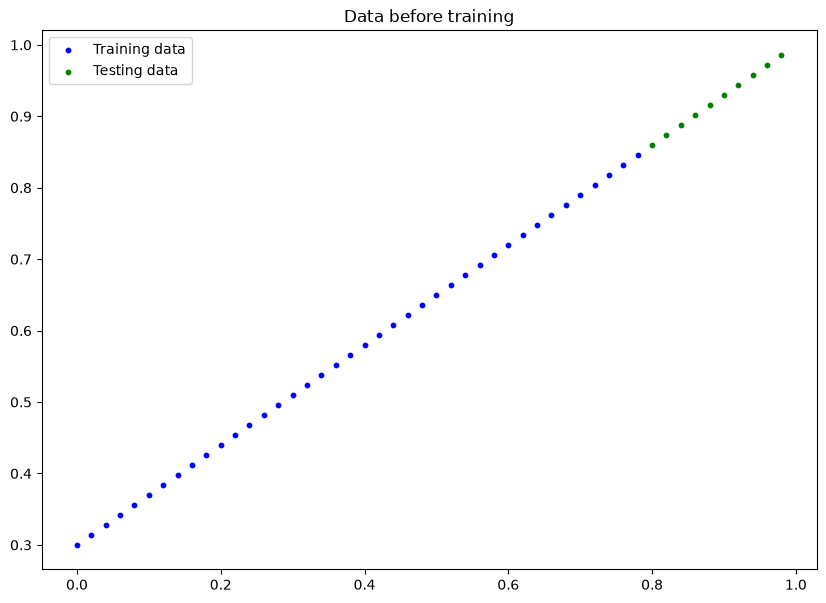

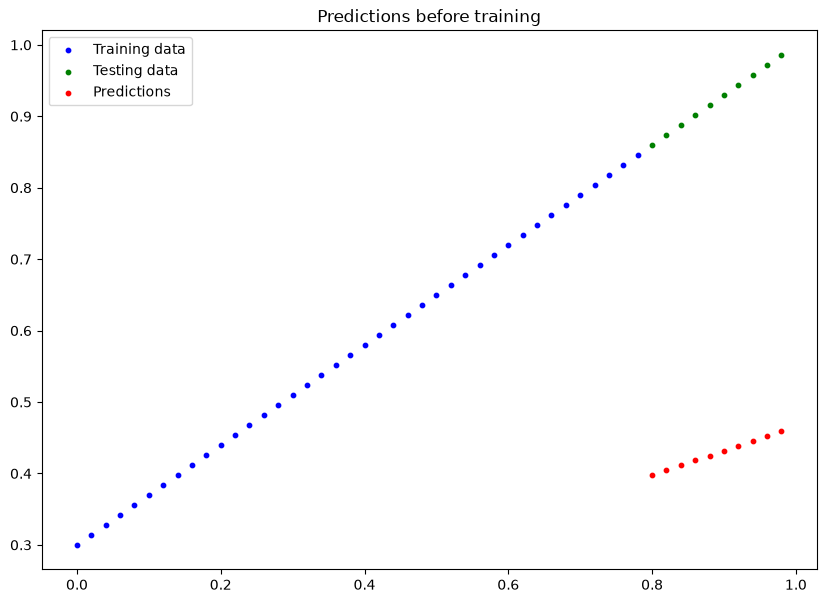

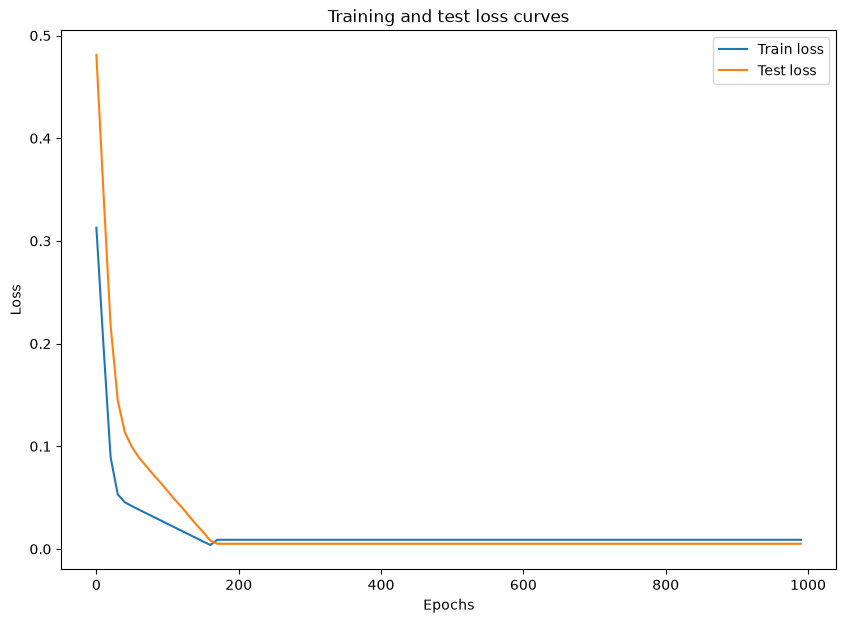

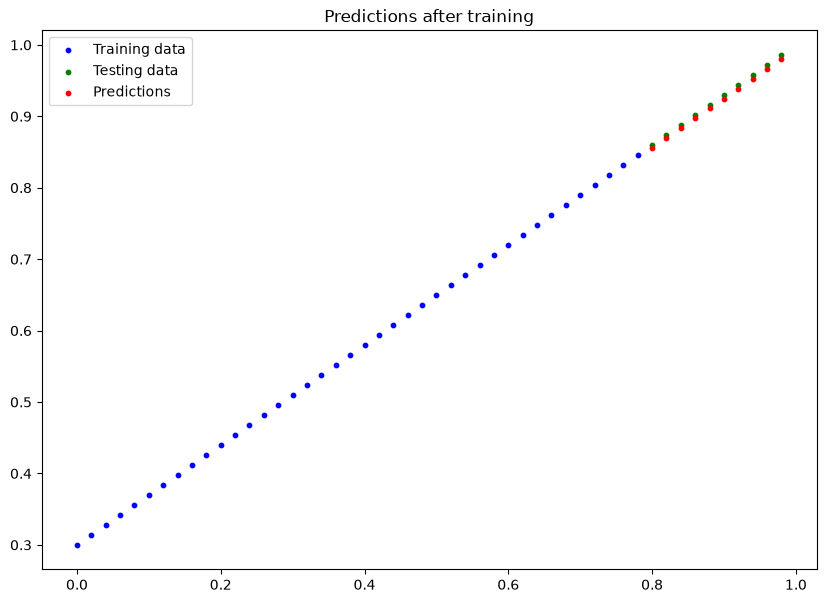

tensor([0.3900])
tensor([1.])


In [5]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. Create data
# ============================================================

# 已知的真实参数
weight = 0.7
bias = 0.3

# 创建数据
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

print("X 前 10 个：")
print(X[:10])

print("\ny 前 10 个：")
print(y[:10])


# ============================================================
# 2. Split data into training/test sets
# ============================================================

train_split = int(0.8 * len(X))

X_train = X[:train_split]
y_train = y[:train_split]

X_test = X[train_split:]
y_test = y[train_split:]

print("\n数据集大小：")
print(f"X_train: {len(X_train)}")
print(f"y_train: {len(y_train)}")
print(f"X_test : {len(X_test)}")
print(f"y_test : {len(y_test)}")


# ============================================================
# 3. Visualization function
# ============================================================

def plot_predictions(
        train_data=X_train,
        train_labels=y_train,
        test_data=X_test,
        test_labels=y_test,
        predictions=None,
        title="Training data and test data"
):
    plt.figure(figsize=(10, 7))

    # Training data
    plt.scatter(
        train_data,
        train_labels,
        c="b",
        s=10,
        label="Training data"
    )

    # Testing data
    plt.scatter(
        test_data,
        test_labels,
        c="g",
        s=10,
        label="Testing data"
    )

    # Predictions
    if predictions is not None:
        plt.scatter(
            test_data,
            predictions,
            c="r",
            s=10,
            label="Predictions"
        )

    plt.title(title)
    plt.legend()


# 训练前的数据
plot_predictions(
    title="Data before training"
)


# ============================================================
# 4. Build model
# ============================================================

class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        # 随机 weight
        self.weights = nn.Parameter(
            torch.randn(
                1,
                requires_grad=True,
                dtype=torch.float
            )
        )

        # 随机 bias
        self.bias = nn.Parameter(
            torch.randn(
                1,
                requires_grad=True,
                dtype=torch.float
            )
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias


# 固定随机种子
torch.manual_seed(42)

model_0 = LinearRegressionModel()


# ============================================================
# 5. 查看模型初始参数
# ============================================================

print("\n==============================")
print("训练前模型参数")
print("==============================")

print(model_0.state_dict())

print("\n真实参数：")
print({
    "weight": weight,
    "bias": bias
})


# ============================================================
# 6. Make predictions before training
# ============================================================

with torch.inference_mode():
    y_preds = model_0(X_test)

print("\n训练前预测：")
print(y_preds)

plot_predictions(
    predictions=y_preds,
    title="Predictions before training"
)


# ============================================================
# 7. Setup Loss Function + Optimizer
# ============================================================

# MAE
loss_fn = nn.L1Loss()

# Stochastic Gradient Descent
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.01
)


# ============================================================
# 8. Training Loop
# ============================================================

epochs = 999

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []


for epoch in range(epochs):

    # ========================================================
    # Training
    # ========================================================

    # 0. Set model to training mode
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Gradient descent
    optimizer.step()


    # ========================================================
    # Testing
    # ========================================================

    model_0.eval()

    with torch.inference_mode():

        # 1. Forward pass
        test_pred = model_0(X_test)

        # 2. Calculate loss
        test_loss = loss_fn(
            test_pred,
            y_test
        )


    # ========================================================
    # Print results
    # ========================================================

    if epoch % 10 == 0:

        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

        print(
            f"Epoch: {epoch:3d} | "
            f"Loss: {loss.item():.5f} | "
            f"Test loss: {test_loss.item():.5f}"
        )

        print(
            model_0.state_dict()
        )


# ============================================================
# 9. Training results table
# ============================================================

results = pd.DataFrame({
    "Epoch": epoch_count,
    "Train Loss": loss_values,
    "Test Loss": test_loss_values
})

print("\n")
print("==============================")
print("Training Results")
print("==============================")

print(
    results.to_string(
        index=False
    )
)


# ============================================================
# 10. Loss Curve
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    epoch_count,
    loss_values,
    label="Train loss"
)

plt.plot(
    epoch_count,
    test_loss_values,
    label="Test loss"
)

plt.title(
    "Training and test loss curves"
)

plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend()


# ============================================================
# 11. Make predictions after training
# ============================================================

model_0.eval()

with torch.inference_mode():
    y_preds_new = model_0(X_test)

print("\n训练后的预测：")
print(y_preds_new)


# ============================================================
# 12. Plot predictions after training
# ============================================================

plot_predictions(
    predictions=y_preds_new,
    title="Predictions after training"
)


# ============================================================
# 13. Final parameters
# ============================================================

print("\n")
print("==============================")
print("训练完成")
print("==============================")

print("模型最终参数：")
print(model_0.state_dict())

print("\n真实参数：")
print({
    "weight": weight,
    "bias": bias
})


# ============================================================
# 14. Compare
# ============================================================

learned_weight = model_0.state_dict()["weights"].item()
learned_bias = model_0.state_dict()["bias"].item()

comparison = pd.DataFrame({
    "Parameter": [
        "weight",
        "bias"
    ],
    "Real Value": [
        weight,
        bias
    ],
    "Learned Value": [
        learned_weight,
        learned_bias
    ]
})

print("\n参数比较：")
print(
    comparison.to_string(
        index=False
    )
)


# 显示所有图
plt.show()
print(model_0.weights.grad)
print(model_0.bias.grad)